# Анализ поисковых запросов в Яндекс Картинках

Данный ноутбук содержит анализ выборки поисковых запросов к сервису Яндекс Картинки. Цель исследования — проверить гипотезу о различии интересов пользователей мобильных устройств (touch) и компьютеров (desktop).

## Подготовка данных

In [11]:
import sys
print(sys.executable)

/Users/nona/Downloads/test_yandex/.venv/bin/python


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
from datetime import datetime

# Настройка визуализации
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
df = pd.read_csv('data.tsv', sep='\t', names=['query', 'timestamp', 'platform'])
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df.head()

,query,timestamp,platform,datetime
0,малевич картины,1631806465,desktop,2021-09-16 15:34:25
1,психология,1631781583,touch,2021-09-16 08:39:43
2,с днём рождения лена,1631771563,touch,2021-09-16 05:52:43
3,зверополис фильмы,1631787599,touch,2021-09-16 10:19:59
4,алабай собака фото,1631786645,touch,2021-09-16 10:04:05


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
from datetime import datetime

# Настройка визуализации
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
df = pd.read_csv('data.tsv', sep='\t', names=['query', 'timestamp', 'platform'])
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df.head()

,query,timestamp,platform,datetime
0,малевич картины,1631806465,desktop,2021-09-16 15:34:25
1,психология,1631781583,touch,2021-09-16 08:39:43
2,с днём рождения лена,1631771563,touch,2021-09-16 05:52:43
3,зверополис фильмы,1631787599,touch,2021-09-16 10:19:59
4,алабай собака фото,1631786645,touch,2021-09-16 10:04:05


### 1. Диапазон дат для анализа
Определим временной интервал, представленный в данных.

In [14]:
min_date = df['datetime'].min()
max_date = df['datetime'].max()

print(f"Данные представлены за период с {min_date} по {max_date}.")
print(f"Общая продолжительность: {max_date - min_date}")

Данные представлены за период с 2021-08-31 21:00:00 по 2021-09-21 20:59:59.
Общая продолжительность: 20 days 23:59:59


### 2. Расчет количества запросов с текстом "ютуб"
Для выполнения этой задачи воспользуемся SQL-запросом через библиотеку `pandasql`.

In [15]:
pysqldf = lambda q: sqldf(q, globals())

query_youtube = """
SELECT 
    platform, 
    COUNT(*) as count 
FROM df 
WHERE "query" LIKE '%ютуб%'
GROUP BY platform
"""

youtube_stats = pysqldf(query_youtube)
print("Количество запросов, содержащих 'ютуб':")
print(youtube_stats)

Количество запросов, содержащих 'ютуб':
  platform  count
0  desktop    802
1    touch    597


### 3. Топ-10 самых частотных запросов в каждой платформе
Сравним популярные запросы на разных устройствах.

In [16]:
top_desktop = df[df['platform'] == 'desktop']['query'].value_counts().head(10)
top_touch = df[df['platform'] == 'touch']['query'].value_counts().head(10)

print("Топ-10 Desktop:")
print(top_desktop)
print("\nТоп-10 Touch:")
print(top_touch)

Топ-10 Desktop:
query
календарь 2021                     2804
таблица менделеева                 2631
картинки                           1647
английский алфавит                 1293
обои на рабочий стол               1143
Одноклассники (социальная сеть)    1116
таблица квадратов                   877
алфавит                             874
таблица умножения                   867
карта мира                          795
Name: count, dtype: int64

Топ-10 Touch:
query
с днём рождения женщине    4903
с днём рождения            3967
с днём рождения мужчине    3623
с днем рождения            3005
погода                     2840
игры                       2833
фильмы                     2746
новости                    2708
музыка                     2696
мода                       2648
Name: count, dtype: int64


**Анализ отличий:**
- **Desktop:** Преобладают утилитарные и образовательные запросы (календарь, таблица Менделеева, английский алфавит, таблица умножения). Это указывает на использование поиска в рабочих или учебных целях.
- **Touch:** Доминируют социально-бытовые и развлекательные запросы (поздравления с днем рождения, погода, игры, фильмы). Пользователи мобильных устройств чаще ищут контент для личного общения и быстрого потребления.

### 4. Отличия трафика в течение дня
Проанализируем распределение активности пользователей по часам.

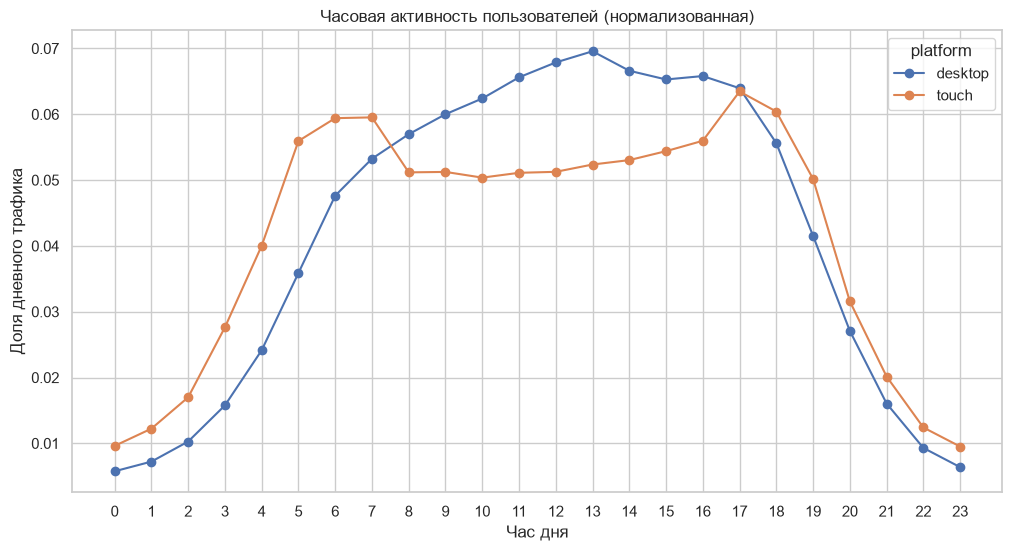

In [17]:
df['hour'] = df['datetime'].dt.hour
hourly_dist = df.groupby(['hour', 'platform']).size().unstack()

# Нормализация для сравнения формы распределения
hourly_dist_norm = hourly_dist.div(hourly_dist.sum(axis=0), axis=1)

hourly_dist_norm.plot(kind='line', marker='o')
plt.title('Часовая активность пользователей (нормализованная)')
plt.xlabel('Час дня')
plt.ylabel('Доля дневного трафика')
plt.xticks(range(0, 24))
plt.show()

**Объяснение отличий:**
- **Desktop** трафик имеет выраженные пики в рабочее время (с 9:00 до 18:00), что подтверждает использование компьютеров для работы и учебы.
- **Touch** трафик более равномерен в течение дня, с заметным ростом в утренние часы (когда люди просыпаются и проверяют новости/погоду) и вечерние часы (личное время, отдых). Минимум активности на обеих платформах приходится на глубокую ночь (3:00-4:00).

### 5. Контрастные тематики
Выделим темы, доля которых существенно отличается на разных платформах.

In [18]:
# Выделим первое слово запроса как категорию
df['category'] = df['query'].str.split().str[0].str.lower()

# Считаем частотность категорий
cat_counts = df.groupby(['category', 'platform']).size().unstack(fill_value=0)
cat_counts = cat_counts[cat_counts.sum(axis=1) > 100] # Отсекаем редкие запросы

# Доли категорий внутри платформ
cat_shares = cat_counts.div(cat_counts.sum(axis=0), axis=1)
cat_shares['diff'] = cat_shares['touch'] - cat_shares['desktop']

print("Темы, характерные для мобильных устройств (Touch):")
print(cat_shares.sort_values('diff', ascending=False).head(5))

print("\nТемы, характерные для компьютеров (Desktop):")
print(cat_shares.sort_values('diff', ascending=True).head(5))

Темы, характерные для мобильных устройств (Touch):
platform       desktop     touch      diff
category                                  
с             0.017062  0.098609  0.081546
доброе        0.002158  0.017955  0.015797
открытки      0.002817  0.013682  0.010865
поздравления  0.003078  0.013241  0.010163
погода        0.003103  0.008524  0.005421

Темы, характерные для компьютеров (Desktop):
platform    desktop     touch      diff
category                               
календарь  0.029290  0.008194 -0.021097
таблица    0.026604  0.009742 -0.016862
раскраски  0.013807  0.000459 -0.013348
раскраска  0.012902  0.000481 -0.012420
обои       0.017348  0.008171 -0.009177


## Заключение

Анализ подтвердил гипотезу: паттерны использования Яндекс Картинок на мобильных устройствах и компьютерах существенно различаются.

1. **Desktop** — это инструмент для «серьезных» задач: поиск справочной информации, образовательных материалов, обоев для рабочего стола и рабочих инструментов.
2. **Touch** — это инструмент для быстрого решения повседневных задач, социального взаимодействия (поздравления) и развлечений.

Эти выводы могут быть использованы для оптимизации интерфейса и алгоритмов ранжирования под конкретную платформу.